In [1]:
from typing_extensions import TypedDict # Defines a Dictionary Schema
class State(TypedDict) :
    graph_info : str 

# state defines the shape of the state object that flow through the graph


In [2]:
def start_play(state : State) :
    """ Start play node has been classed """
    return {"graph_info" : state["graph_info"] + "I am playing"}


def cricket(state : State) :
    print("My Cricket node ha")

In [4]:
from dotenv import load_dotenv
load_dotenv
import os

In [5]:
api_key = os.getenv("claudeAPI")
groqAPI = os.getenv("groqAPI")


In [6]:
from langchain_anthropic import ChatAnthropic

claude = ChatAnthropic(
    model = "claude-haiku-4-5-20251001",
    temperature = 0.7,
    api_key = api_key
)

In [7]:
from langchain_groq import ChatGroq
groq = ChatGroq(
    model = "qwen/qwen3-32b",
    api_key = groqAPI
)

In [ ]:
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content = f"How can I help you today ? ", name = "LLMModel")]
messages.append(HumanMessage(content= f"I want to learn a programming language", name = "Akash"))
messages.append(AIMessage(content = f"Which programming Language do you want to learn",name = "LLMModel"))
messages.append(HumanMessage(content = f"I want to learn Kotlin", name = "Akash"))




In [18]:
from pprint import pprint

for message in messages :
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

How can I help you today ?
================================ Human Message =================================
Name: Akash

I want to learn a programming language
================================== Ai Message ==================================
Name: LLMModel

Which programming Language do you want to learn
================================ Human Message =================================
Name: Akash

I want to learn Kotlin


In [20]:
result =groq.invoke(messages)

In [ ]:
result.response_metadata    

{'token_usage': {'completion_tokens': 1530,
  'prompt_tokens': 56,
  'total_tokens': 1586,
  'completion_time': 9.853409964,
  'completion_tokens_details': None,
  'prompt_time': 0.005014869,
  'prompt_tokens_details': None,
  'queue_time': 0.150419808,
  'total_time': 9.858424833},
 'model_name': 'qwen/qwen3-32b',
 'system_fingerprint': 'fp_efa9879028',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

In [22]:
def add (a: int, b : int) -> int :
    """  Add a and b  """
    return a+b

    

llm.invoke() takes string a input and list of strings 

In [ ]:
## Bind tool with LLM
llm_tool = groq.bind_tools([add])
llm_tool.invoke([HumanMessage(content = f"what is 2 plus 2", name = "Akash")])




AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is 2 plus 2". Let me see. I need to figure out if I should use the add function provided. The function takes two integers, a and b. The user\'s question is straightforward addition. So, 2 plus 2 is the same as adding 2 and 2. The parameters required are a and b, both integers. I should call the add function with a=2 and b=2. That should give the correct result. No other functions are available, so this is the right choice.\n', 'tool_calls': [{'id': 'rdcp532vy', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 144, 'prompt_tokens': 163, 'total_tokens': 307, 'completion_time': 0.232920141, 'completion_tokens_details': {'reasoning_tokens': 115}, 'prompt_time': 0.020053293, 'prompt_tokens_details': None, 'queue_time': 0.076843529, 'total_time': 0.252973434}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint'

In [27]:
tool_call = llm_tool.invoke([HumanMessage(content = f"what is 2 plus 2", name = "Akash")])
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': '52rs7zv5g',
  'type': 'tool_call'}]

In [43]:
## Using these messages as state

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict) :
    message : list[AnyMessage] # will be overriden


In [44]:
from langgraph.graph.message import add_messages
from typing import Annotated # reducer

class State(TypedDict) :
    message :Annotated[list[AnyMessage], add_messages]

In [45]:
initial_messages = [AIMessage(content = f"How can I help you today ? ", name = "LLMModel")]
initial_messages.append(HumanMessage(content= f"I want to learn a programming language", name = "Akash"))


In [46]:
next_messages = [(AIMessage(content = f"Which programming Language do you want to learn",name = "LLMModel"))]
next_messages.append(HumanMessage(content = f"I want to learn Kotlin", name = "Akash"))

### Reducers with add_messages

In [47]:
add_messages(initial_messages, next_messages)

[AIMessage(content='How can I help you today ? ', additional_kwargs={}, response_metadata={}, name='LLMModel', id='c3475ca5-0865-495c-bbfa-17e83e760e69'),
 HumanMessage(content='I want to learn a programming language', additional_kwargs={}, response_metadata={}, name='Akash', id='fff394d1-3de1-4206-83d8-afd4a248c934'),
 AIMessage(content='Which programming Language do you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='7439ec6c-538a-4140-ad90-1bd0f6331b13'),
 HumanMessage(content='I want to learn Kotlin', additional_kwargs={}, response_metadata={}, name='Akash', id='af37e546-c9ef-45fa-9328-20b9cd26db1a')]

In [48]:

def tool (state : State) :
    return {"messages" : [llm_tool.invoke(state["message"])]}

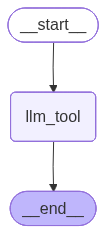

In [49]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


builder = StateGraph(State)
builder.add_node('llm_tool', tool)

# adding edges
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [ ]:
# import the document and create the chunks


### Learn how to remove unnecessary space in b/w the docs

In [ ]:
urls = ["https://www.ibm.com/think/topics/agentic-ai-vs-generative-ai#7281538", "https://docs.databricks.com/aws/en/generative-ai/agent-bricks/key-info-extraction"]

loaders = [WebBaseLoader(url) for url in urls]
docs = []

# loaders contains the docs in the form of WebBaseLoader() need to implement load() to make it a document

for loader in loaders :
    docs.extend(loader.load())


splitter = RecursiveCharacterTextSplitter(
    chunk_size=  500,
    chunk_overlap = 50)

chunks = splitter.split_documents(docs)


vectorstore = FAISS.from_documents(chunks, Embeddings)
retriever = vectorstore.as_retriever()


In [ ]:
result = retriever.invoke("what is Generative AI")
print(result[0].page_content[0:500])

Diving into the differences between agentic AI and generative AI means first defining both.
Generative AI is artificial intelligence that can create original content—such as text, images, video, audio or software code—in response to a user’s prompt or request. Gen AI relies on using machine learning models called deep learning models—algorithms that simulate the learning and decision-making processes of the human brain—and other technologies like robotic process automation (RPA).


In [41]:
print("\n".join(doc.page_content for doc in result))





Diving into the differences between agentic AI and generative AI means first defining both.
Generative AI is artificial intelligence that can create original content—such as text, images, video, audio or software code—in response to a user’s prompt or request. Gen AI relies on using machine learning models called deep learning models—algorithms that simulate the learning and decision-making processes of the human brain—and other technologies like robotic process automation (RPA).
Amanda Downie

Staff Editor
IBM Think






Artificial intelligence (AI) has been a popular topic for the past decade, but more recently terms such as generative AI (gen AI) and agentic AI have emerged. While traditional AI offered users an exciting new way to recognize patterns and analyze data, gen AI can create new patterns and content like text, images, video, audio or software code.
Data analysis: Generative AI can analyze vast amounts of data and use that analysis to discover patterns and trends. The gen

In [3]:
import pandas as pd

In [ ]:
employees = pd.DataFrame({
    "emp_id": [1, 1, 1, 2, 2],
    "event_day": ["2020-11-28", "2020-11-28", "2020-12-03", "2020-11-28", "2020-12-09"],
    "in_time": [4, 55, 1, 3, 47],
    "out_time": [32, 200, 42, 33, 74]
})



In [ ]:
import pandas as pd

samples = pd.DataFrame({
    "sample_id": [1, 2, 3, 4, 5, 6, 7],
    "dna_sequence": [
        "ATGCTAGCTAGCTAA",
        "GGGTCAATCATC",
        "ATATATCGTAGCTA",
        "ATGGGGTCATCATAA",
        "TCAGTCAGTCAG",
        "ATATCGCGCTAG",
        "CGTATGCGTCGTA"
    ],
    "species": [
        "Human",
        "Human",
        "Human",
        "Mouse",
        "Mouse",
        "Zebrafish",
        "Zebrafish"
    ]
})



In [62]:
import os
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END,StateGraph
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages # reducer -> it tells langGraph to merge the updates messages
from dotenv import load_dotenv
from typing import List, Annotated


In [ ]:
# Load the document
from langchain_community.document_loaders import TextLoader


Embeddings = HuggingFaceEmbeddings(
   model_name = "sentence-transformers/all-MiniLM-L6-v2"
)
docs = TextLoader("/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/AutomnomousRAG/research_notes.txt").load()
chunks = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50).split_documents(docs)
vs= FAISS.from_documents(chunks, Embeddings)
retriever = vs.as_retriever()

In [13]:
retriever.invoke("what are transformers")

[Document(id='531f4e42-298b-4bd7-bb2e-282f047b44ad', metadata={'source': '/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/AutomnomousRAG/research_notes.txt'}, page_content='Experiment Log: Transformer Evaluation - July 2024\n\nEfficientFormer:\n- Top-1 accuracy: 92.4% on TinyImageNet\n- Peak memory usage: 290MB (batch size = 16)\n- Deployment target: Raspberry Pi 4\n- Notes: Works well in quantized int8 mode with no major accuracy drop\n\nLongformer:\n- Evaluation on customer support logs (max tokens: 8192)\n- Latency >1.2s per query in streaming setting\n- Observations: Chunk-based hybrid attention may reduce delay'),
 Document(id='42261549-f7a7-4bc1-b0a6-fb75783492f7', metadata={'source': '/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/AutomnomousRAG/research_notes.txt'}, page_content='TinyBERT:\n- Used for classification: Support ticket priority tagging\n- Evaluation: 87% F1 score, confusion in ambiguous class C\n- Works well with 2-layer FFN adapter for domain transfer\n

In [14]:
from langchain_anthropic import ChatAnthropic


load_dotenv()
api_key  = os.getenv("claudeAPI")

llm = ChatAnthropic(
    model = "claude-haiku-4-5-20251001",
    temperature = 0.7,
    api_key = api_key
)

In [ ]:
from pydantic import BaseModel
from typing import List
from langchain_core.documents import Document

class COT(BaseModel) :
    question : str = ""
    sub_question : List[str] = []
    retrieved_docs : List[Document] = []
    answer : str = ""


def break_question(state : COT) -> COT :
    prompt = f""" 
    Break the complex question into 2-3 smaller states
    Question :
    {state.question}
    
    and give me smaller question chunks
    """

    result = llm.invoke(prompt).content
    sub_question = [line.strip("- ").strip() for line in result.split("\n") if line.strip() and not line.strip().startswith("#")]
    return state.model_copy(update = {"sub_question" : sub_question})
    
    
def retriever_docs(state : COT)  -> COT :
    outputs  = []
    
    for question in  state.sub_question :
        ans = retriever.invoke(question)
        outputs.extend(ans)

    return state.model_copy(update = {"retrieved_docs" : outputs})


def generate_answer(state : COT) -> COT  :
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""
    Your are answering a complex question. Generate a well formed answer using the provided Context
    
    Question : {state.question}

    Context : {context}
    """
    answer = llm.invoke(prompt).content
    return state.model_copy(update = {"answer" : answer})
    

    
## Graph

builder = StateGraph(COT)

builder.add_node("break", break_question)
builder.add_node("retriever", retriever_docs)
builder.add_node("answer", generate_answer)

builder.set_entry_point("break")
builder.add_edge("break", "retriever")
builder.add_edge("retriever", "answer")
builder.add_edge("answer", END)


graph = builder.compile()


ans = graph.invoke({"question" : "what are the additional experiements in Tranform evaluation"})
